<div style="border: 5px solid purple; padding: 15px; margin: 5px">
<b> Reviewer's comment 2</b>


Thank you so much for the updates! This project is hard and very time-consuming because of heavy models. You did an excellent job here, and I hope you enjoyed it.
    
    
I've left a couple of new comments with digit 2. However, I do not have any questions, so the project can be accepted. 
    
    

    
Good luck! 

    
</div>

<div style="border: 5px solid purple; padding: 15px; margin: 5px">
<b> Reviewer's comment</b>
    
Hi, my name is Svetlana (https://hub.tripleten.com/u/855fe797). Congratulations on submitting another project! 🎉  I will be using the standard color marking. 
   
    
<div style="border: 5px solid green; padding: 15px; margin: 5px">

Great solutions and ideas that can and should be used in the future are in green comments. You have successfully normalized the `review` column, employed advanced techniques such as lemmatization and vectorizing, trained multiple models including a dummy baseline, and applied the `evaluate_model()` method for their assessment. Great job! The results look very good.

</div>
    
<div style="border: 5px solid gold; padding: 15px; margin: 5px">
<b> Reviewer's comment </b>

Yellow color indicates what should be optimized. This is not necessary, but it will be great if you make changes to this project. 

        
</div>
<div style="border: 5px solid red; padding: 15px; margin: 5px">
<b> Reviewer's comment </b>

Issues that must be corrected to achieve accurate results are indicated in red comments. Please note that the project cannot be accepted until these issues are resolved. 
</div>        
<hr>
    
<font color='dodgerblue'>**To sum up:**</font> thank you for such an excellent job! You showed strong coding skills and a solid understanding of this topic, which is quite hard. I hope you enjoyed working on this project. The updates should not take much time. If you have any questions, please feel free to ask. I will wait the project for the second review 😊 
    

<hr>
    
Please use some color other than those listed to highlight answers to my comments.
I would also ask you **not to change, move or delete my comments** to make it easier for me to navigate during the next review.
    
<hr> 
    
✍️ If you are interested in Large Language Models, check out [Intro to Large Language Models](https://www.youtube.com/watch?v=zjkBMFhNj_g) and [Tokenization lecture](https://www.youtube.com/watch?v=zduSFxRajkE) by Andrej Karpathy, one of the leading scientists in this area.  He has also recently published a nice [Deep Dive into LLMs like ChatGPT](https://www.youtube.com/watch?v=7xTGNNLPyMI) tutorial where he explains all LLM preparation stages and a very useful video about how he uses LLM [here](https://www.youtube.com/watch?v=EWvNQjAaOHw&feature=youtu.be). This is a comprehensive guide on how to choose the optimal tool for your tasks while saving time and money.
 
    
    
I would also like to recommend this new <font color='purple'>**Language Modeling from Scratch Spring 2025 class by Stanford**</font>. This class has just started. There are three links: [Recorded lectures on Youtube](https://www.youtube.com/playlist?list=PLoROMvodv4rOY23Y0BoGoBGgQ1zmU_MT_), [course website](https://stanford-cs336.github.io/spring2025/), and the [GitHub repository with assignments and jupyter notebooks](https://github.com/stanford-cs336). This course is up-to-date, so the information there is super relevant today.

    
    
By the way, Hugging Face has a good free [NLP course](https://huggingface.co/learn/nlp-course/en/chapter0/1).
    
    
Here's a link to [AI for beginners](https://github.com/microsoft/ai-for-beginners) course by Microsoft. 
        
    
    

</div>

# Project Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

## Initialization

In [31]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

In [32]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [33]:

# this is to use progress_apply, read more at https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()


## Load Data

In [34]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [35]:
df_reviews.head()

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


In [36]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [37]:
print(df_reviews['pos'].value_counts())
print()
print(df_reviews['ds_part'].value_counts())

0    23715
1    23616
Name: pos, dtype: int64

train    23796
test     23535
Name: ds_part, dtype: int64


## EDA

Let's check the number of movies and reviews over years.

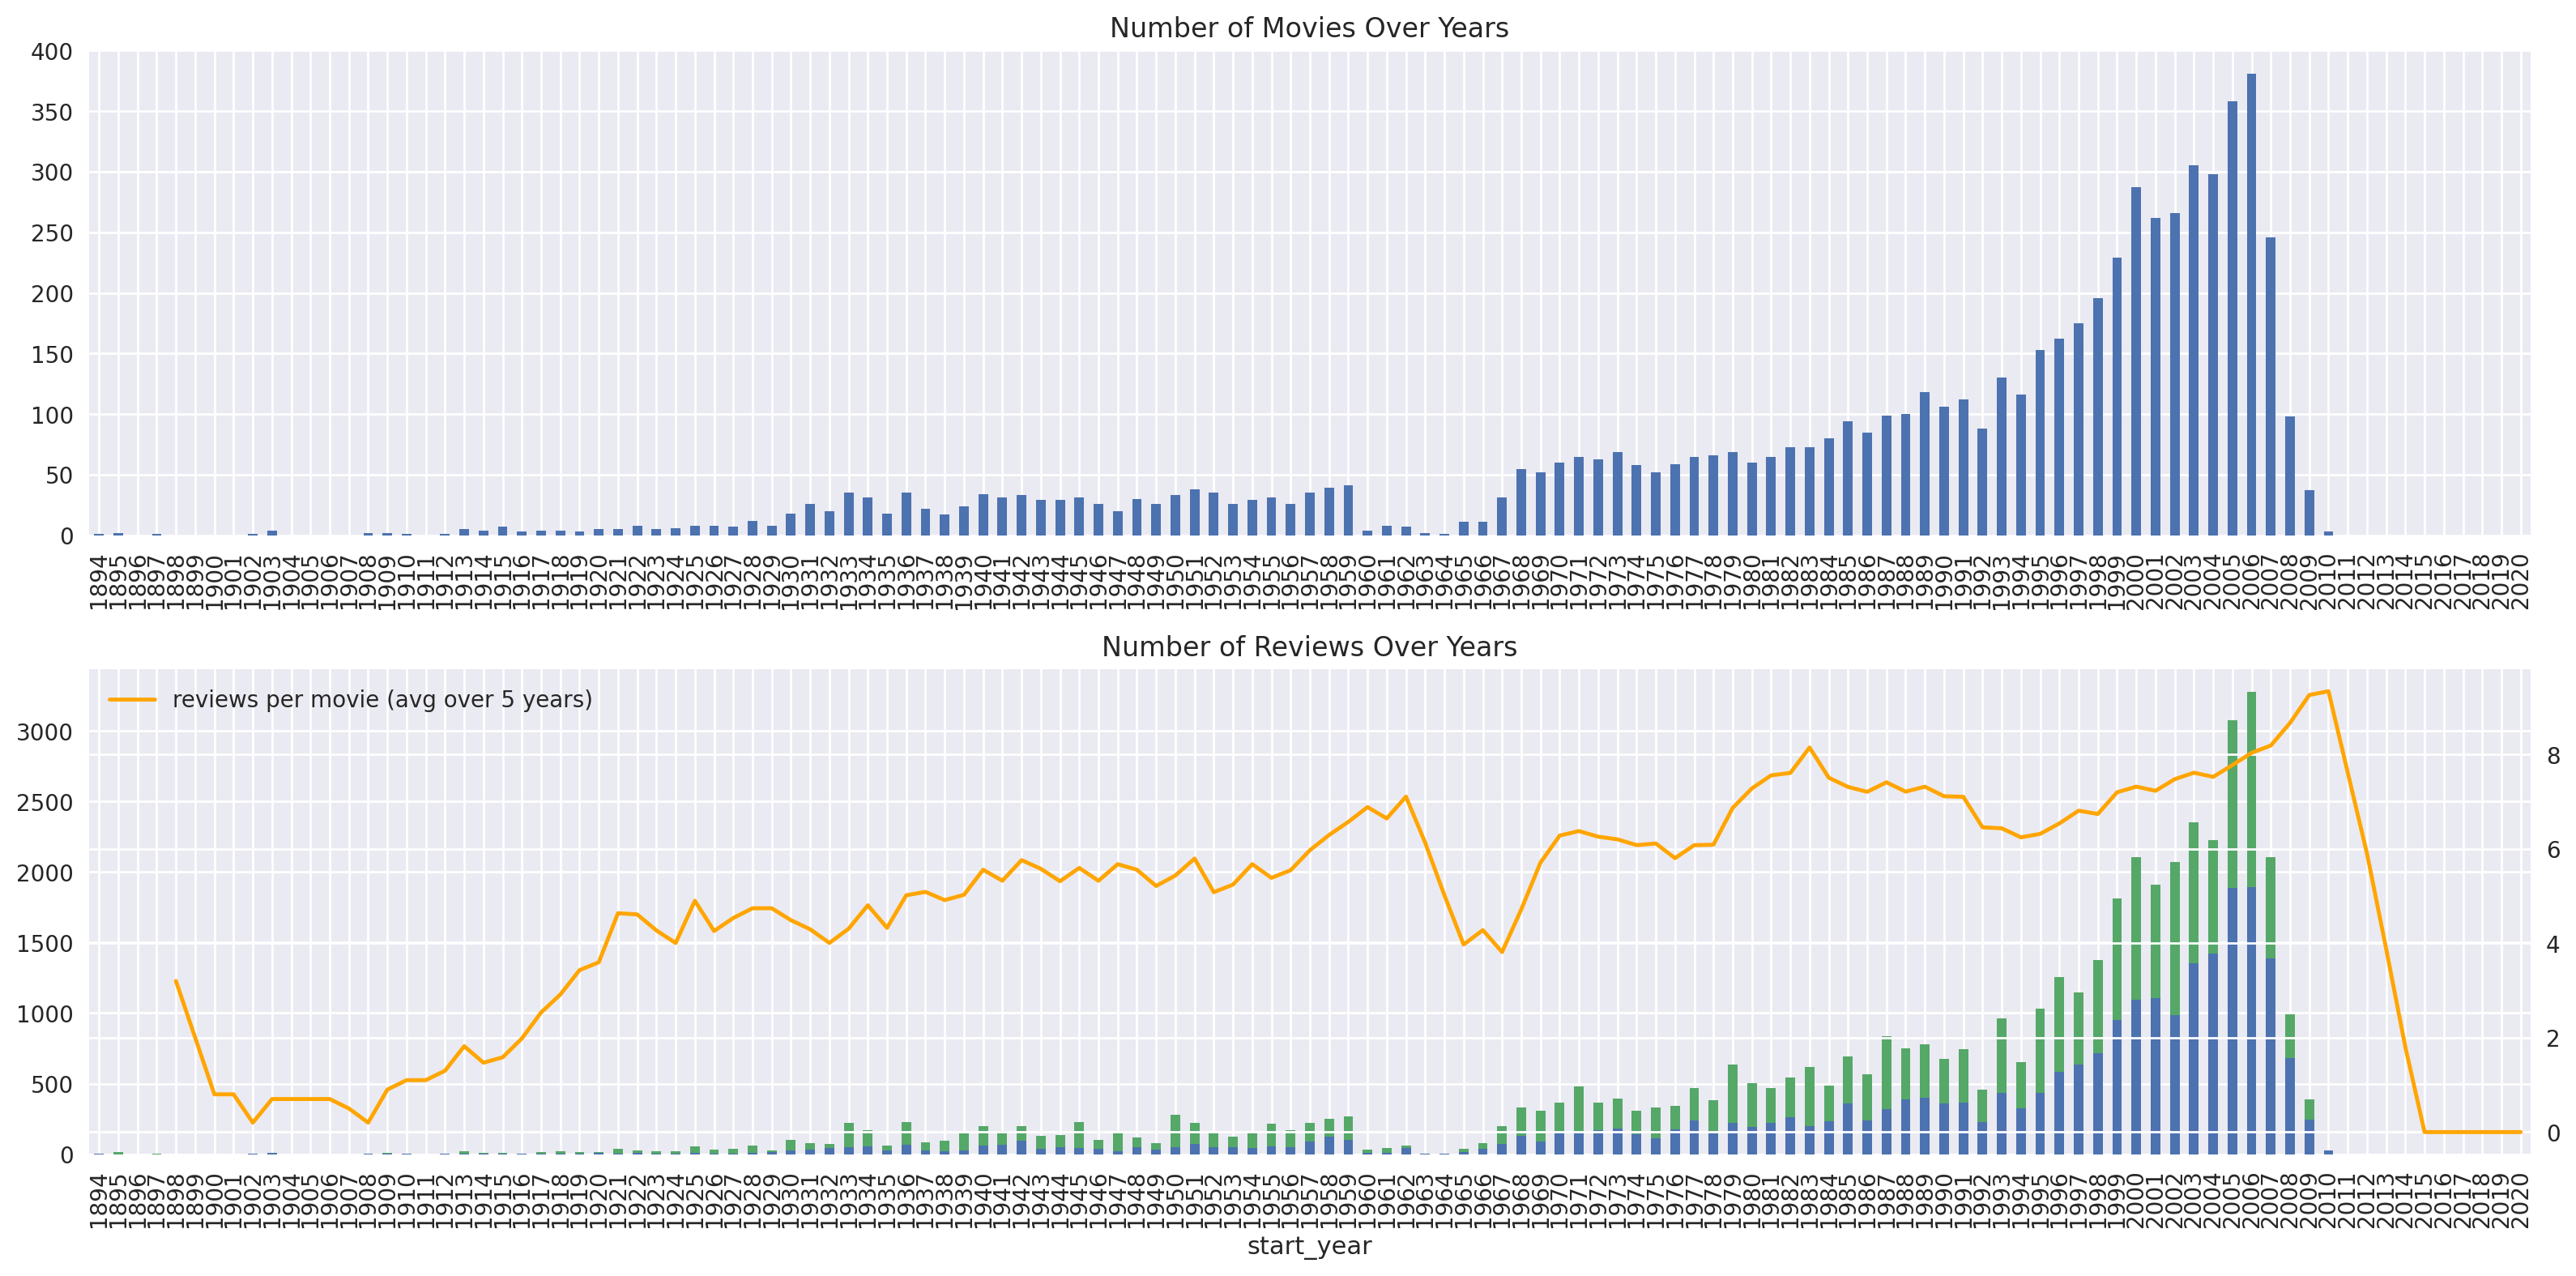

In [38]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

Let's check the distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

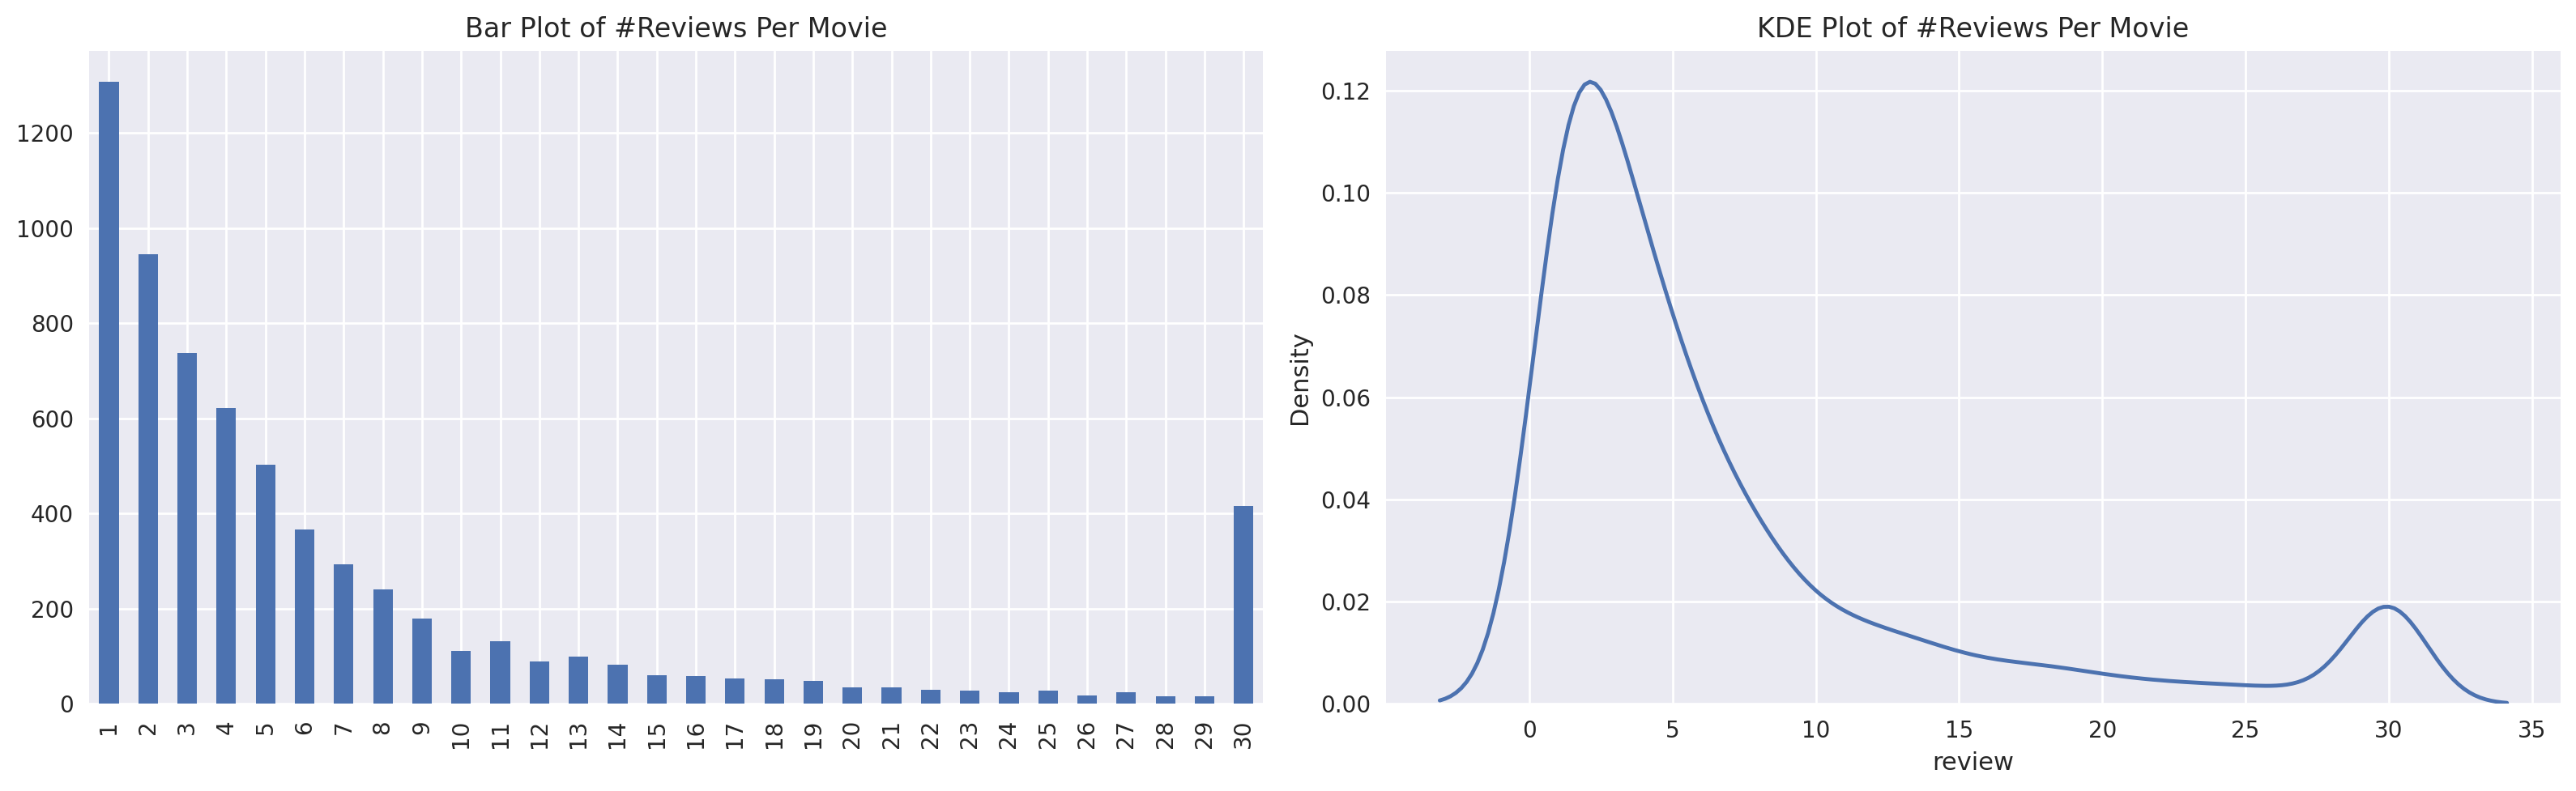

In [39]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

In [40]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [41]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

In [42]:
df_reviews['ds_part'].value_counts()

train    23796
test     23535
Name: ds_part, dtype: int64

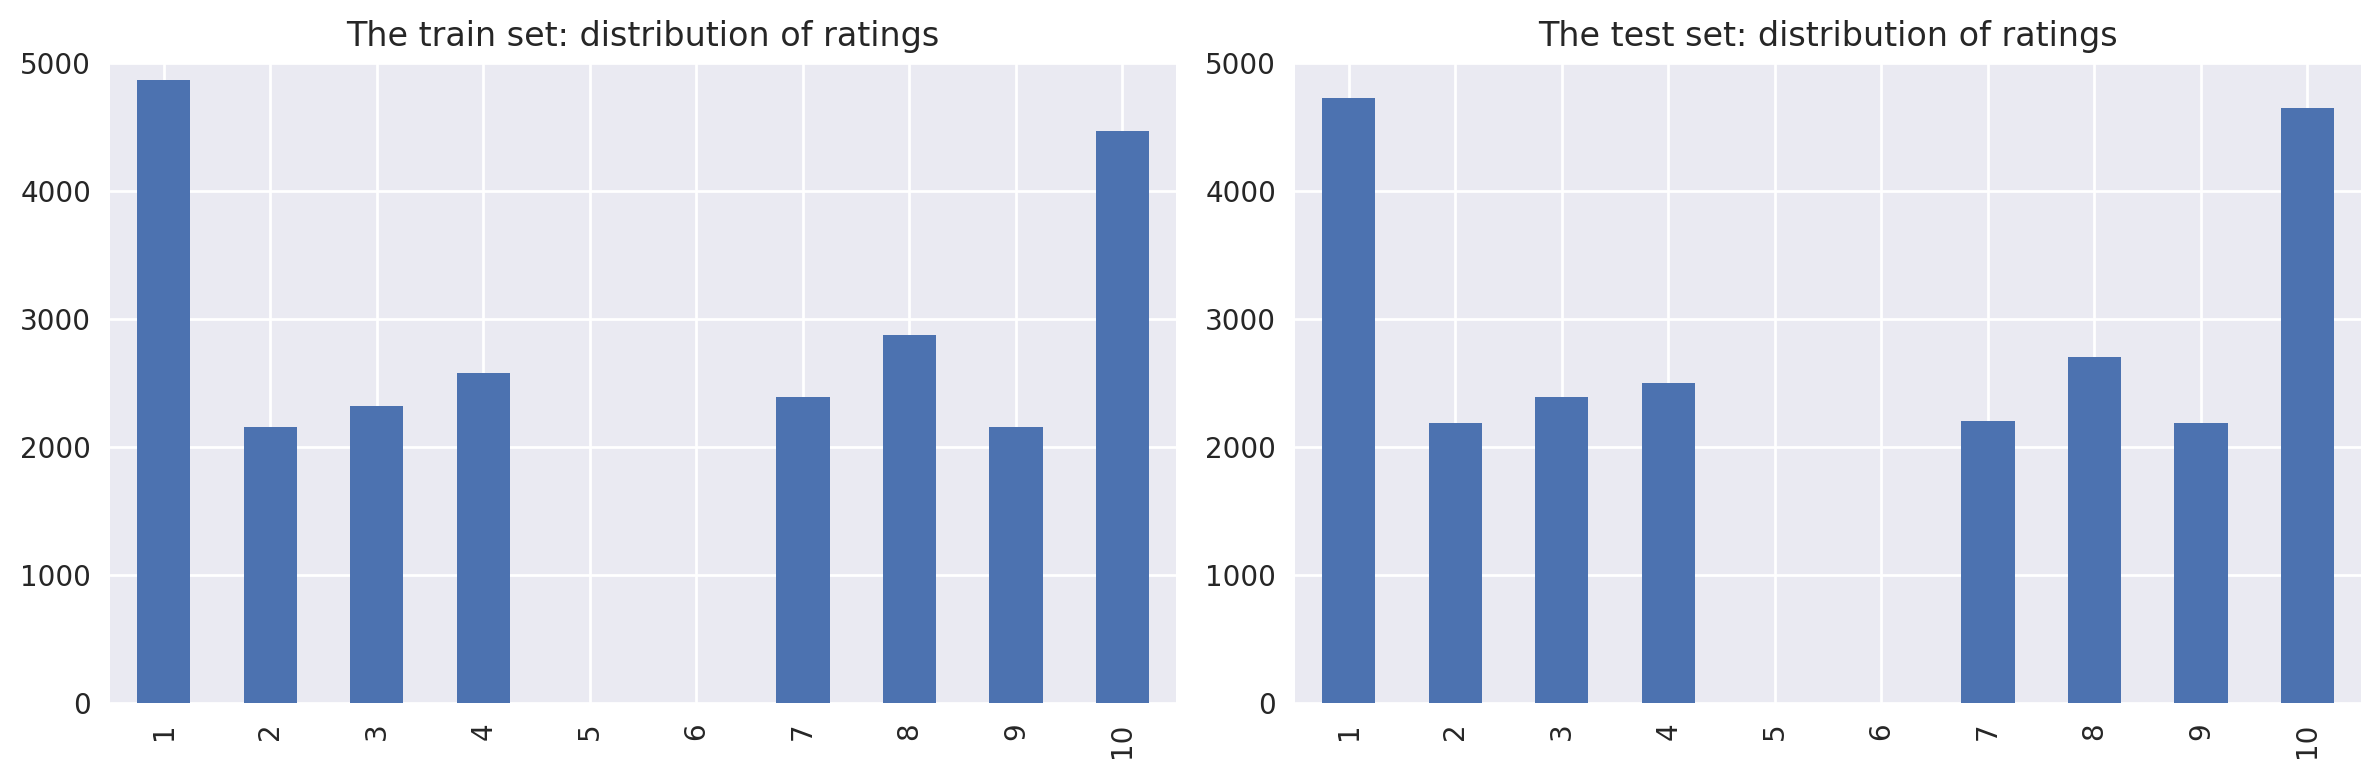

In [43]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

In [44]:
train_class_balance = (
    df_reviews.query('ds_part == "train"')['pos']
    .value_counts(normalize=True)
    .sort_index()
)

test_class_balance = (
    df_reviews.query('ds_part =="test"')['pos']
    .value_counts(normalize=True)
    .sort_index()
)

print("Train set class proportions:")
print(train_class_balance)

print("\nTest set class proportions:")
print(test_class_balance)

Train set class proportions:
0    0.500588
1    0.499412
Name: pos, dtype: float64

Test set class proportions:
0    0.501508
1    0.498492
Name: pos, dtype: float64


Distribution of negative and positive reviews over the years for two parts of the dataset

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)


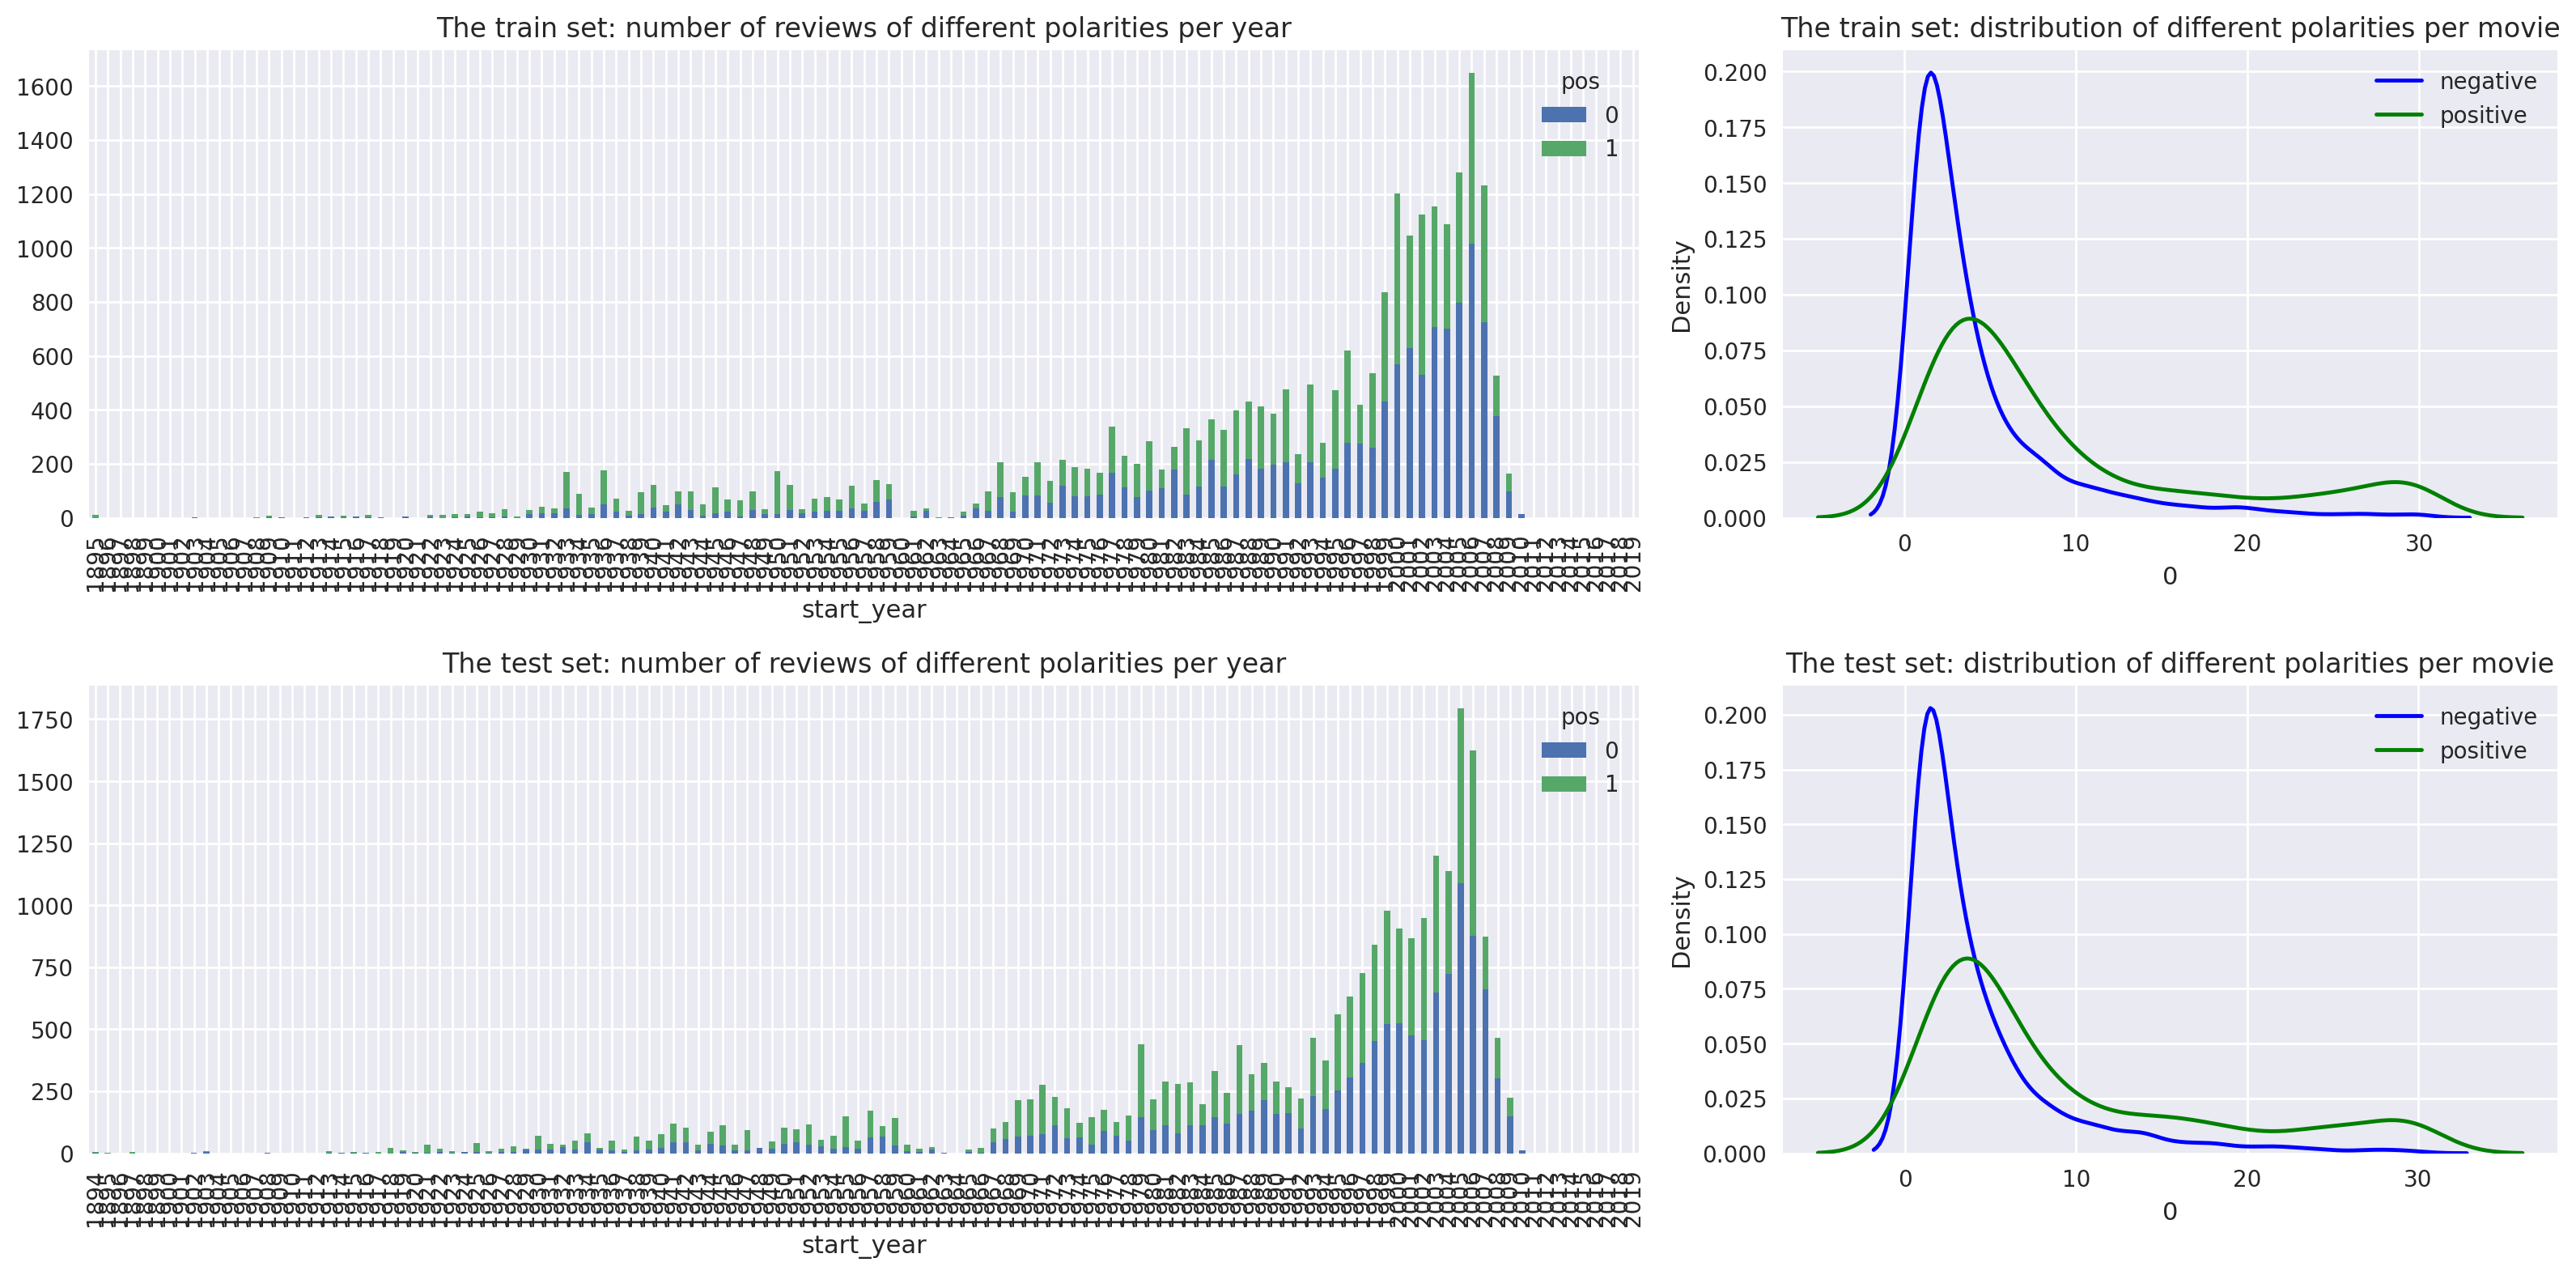

In [45]:

fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()


# Conclusion

The train and test datasets have a similar distribution of positive and negative reviews, with each class representing approximately half of the reviews. 
Therefore, there is no significant class imbalance. The distributions of reviews across movie release years are also broadly similar between the training and test sets.Based onthe EDA, the datasets appear suitable for training and evaluating a binary sentiment classification model. 

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    

Good job here! 

</div>

## Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [46]:

import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return


<div style="border: 5px solid green; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    
I know it was in the precode, but it is a great opportunity to point out the following: 


- According to [PEP8](https://peps.python.org/pep-0008/), we should always put imports at the top of the file.   


- Notice that the `type` veriable is green in the function above. When we see that your variables are green, we should think of another name, since green color indicates that this name is reserved in python. 
    
    
</div>

## Normalization

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [47]:
df_reviews['review_norm'] = (
    df_reviews['review']
        .str.lower()
        .str.replace(r'\d+', ' ', regex=True)
        .str.replace(r'[^\w\s]', ' ', regex=True)
)

In [48]:
df_reviews[['review', 'review_norm']].head()

,review,review_norm
0,The pakage implies that Warren Beatty and Gold...,the pakage implies that warren beatty and gold...
1,How the hell did they get this made?! Presenti...,how the hell did they get this made presenti...
2,There is no real story the film seems more lik...,there is no real story the film seems more lik...
3,Um .... a serious film about troubled teens in...,um a serious film about troubled teens in...
4,I'm totally agree with GarryJohal from Singapo...,i m totally agree with garryjohal from singapo...


<div style="border: 5px solid red; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    

> `df_reviews['review_norm'] = df_reviews['review']`

Does it do anything?


Since we assume that all models below accept texts in lowercase and without any digits, punctuations marks etc., let's preprocess the data. This is because `TfidfVectorizer` by itself does not clean the text, except for removing stop words if specified. Punctuation and digits can create useless tokens such as '123' or '!!', thus increasing dimensionality without adding value. As a result, it may reduce the model's generalization ability.
    

</div>

Updated the review_norm section as requested. The text normalization step is now clearly defined and applied to the training data before proceeding with model training.

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment 2 </b>
    

Correct.

</div>

## Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [49]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


## Working with models

### Model 0 - Constant

In [50]:
from sklearn.dummy import DummyClassifier

In [51]:
model_0 = DummyClassifier(strategy='most_frequent', random_state=12345)

model_0.fit(df_reviews_train['review_norm'], train_target)

DummyClassifier(random_state=12345, strategy='most_frequent')

In [52]:

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
model_0_pred = model_0.predict(df_reviews_test['review_norm'])
print('Accuracy:', accuracy_score(test_target, model_0_pred))
print('F1:', f1_score(test_target, model_0_pred))


Accuracy: 0.5015083917569577
F1: 0.0


<div style="border: 5px solid red; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    
    
Is it enough to just fit the model? Please try to calculate metrics and evaluate the model.

</div>

Model Zero is now calcualted and evaluated as requested with accuracy and F1 score calculated and reported.

<div style="border: 5px solid red; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>


Consider making your project organize. This section is called `Model 0 - Constant`, so here we should only work with the constannt model. Anything related to other models should be moved to the corresponding sections. 
</div>

<div style="border: 5px solid red; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    
    
What can you say about this model? 
</div>

Reorganized this section to clarify that Model One was trained in the preceding section and that the results shown here are for evaluating that trained model.

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment 2 </b>
    

Looks great! 

</div>

# Conclusion
Model Zero provides a baseline for evaluating the performance of the other models. Its accuracy and F1 score show how well a simple constant classifier performs without using the review text features. The subsequent models should be compared against this baseline to determine whether using text features and machine learning improves classification performance.

### Model 1 - NLTK, TF-IDF and LR

<div style="border: 5px solid red; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    
    
Please note that this model was trained in the section above. 
</div>

In [53]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2, max_df=0.95)

train_features_1 = vectorizer.fit_transform(df_reviews_train['review_norm'])
test_features_1 = vectorizer.transform(df_reviews_test['review_norm'])

print("Training features shape:", train_features_1.shape)
print("Test features shape:", test_features_1.shape)

Training features shape: (23796, 50000)
Test features shape: (23535, 50000)


In [55]:
model_1 = LogisticRegression(max_iter=1000, random_state=12345)
model_1.fit(train_features_1, train_target)

LogisticRegression(max_iter=1000, random_state=12345)

          train  test
Accuracy   0.95  0.89
F1         0.95  0.89
APS        0.99  0.96
ROC AUC    0.99  0.96


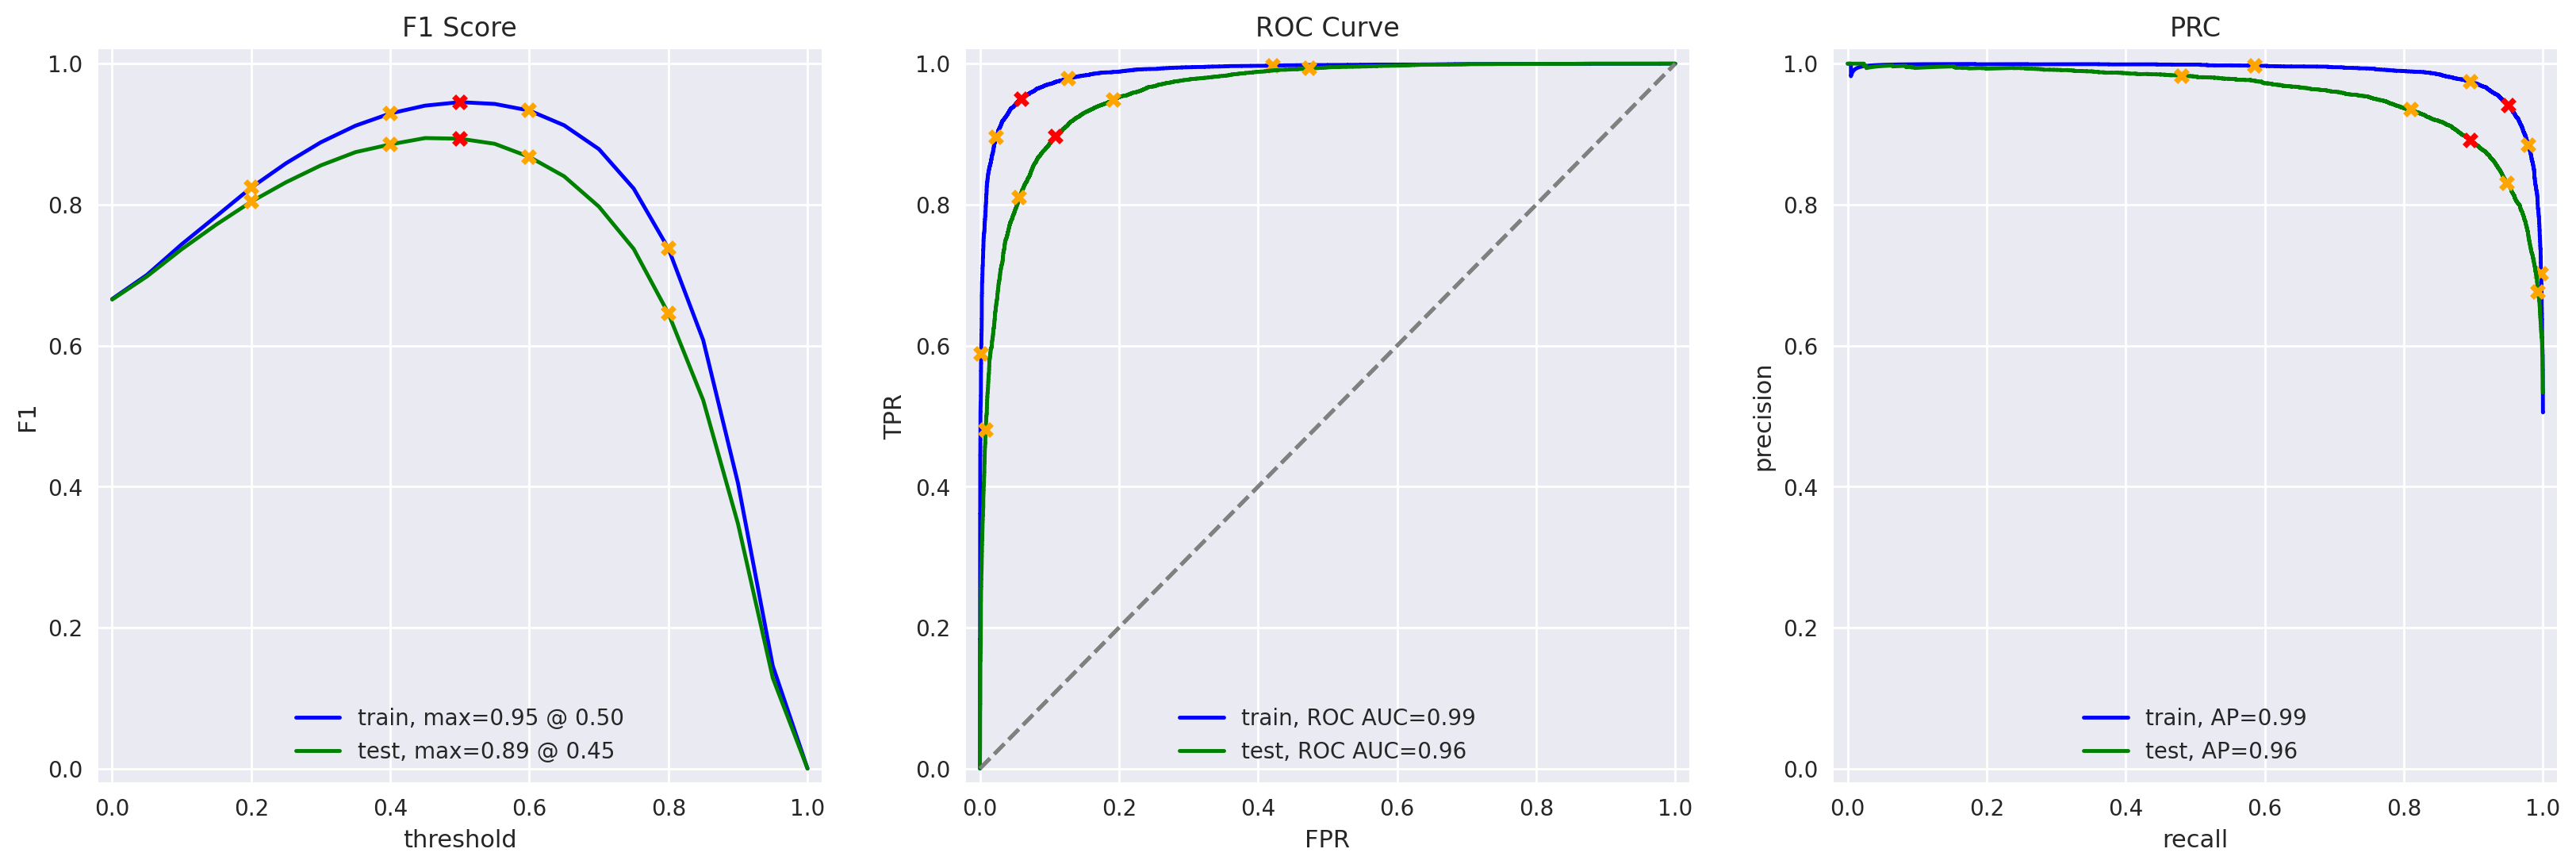

In [56]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment 2 </b>
    

Good. 
</div>

          train  test
Accuracy   0.95  0.89
F1         0.95  0.89
APS        0.99  0.96
ROC AUC    0.99  0.96


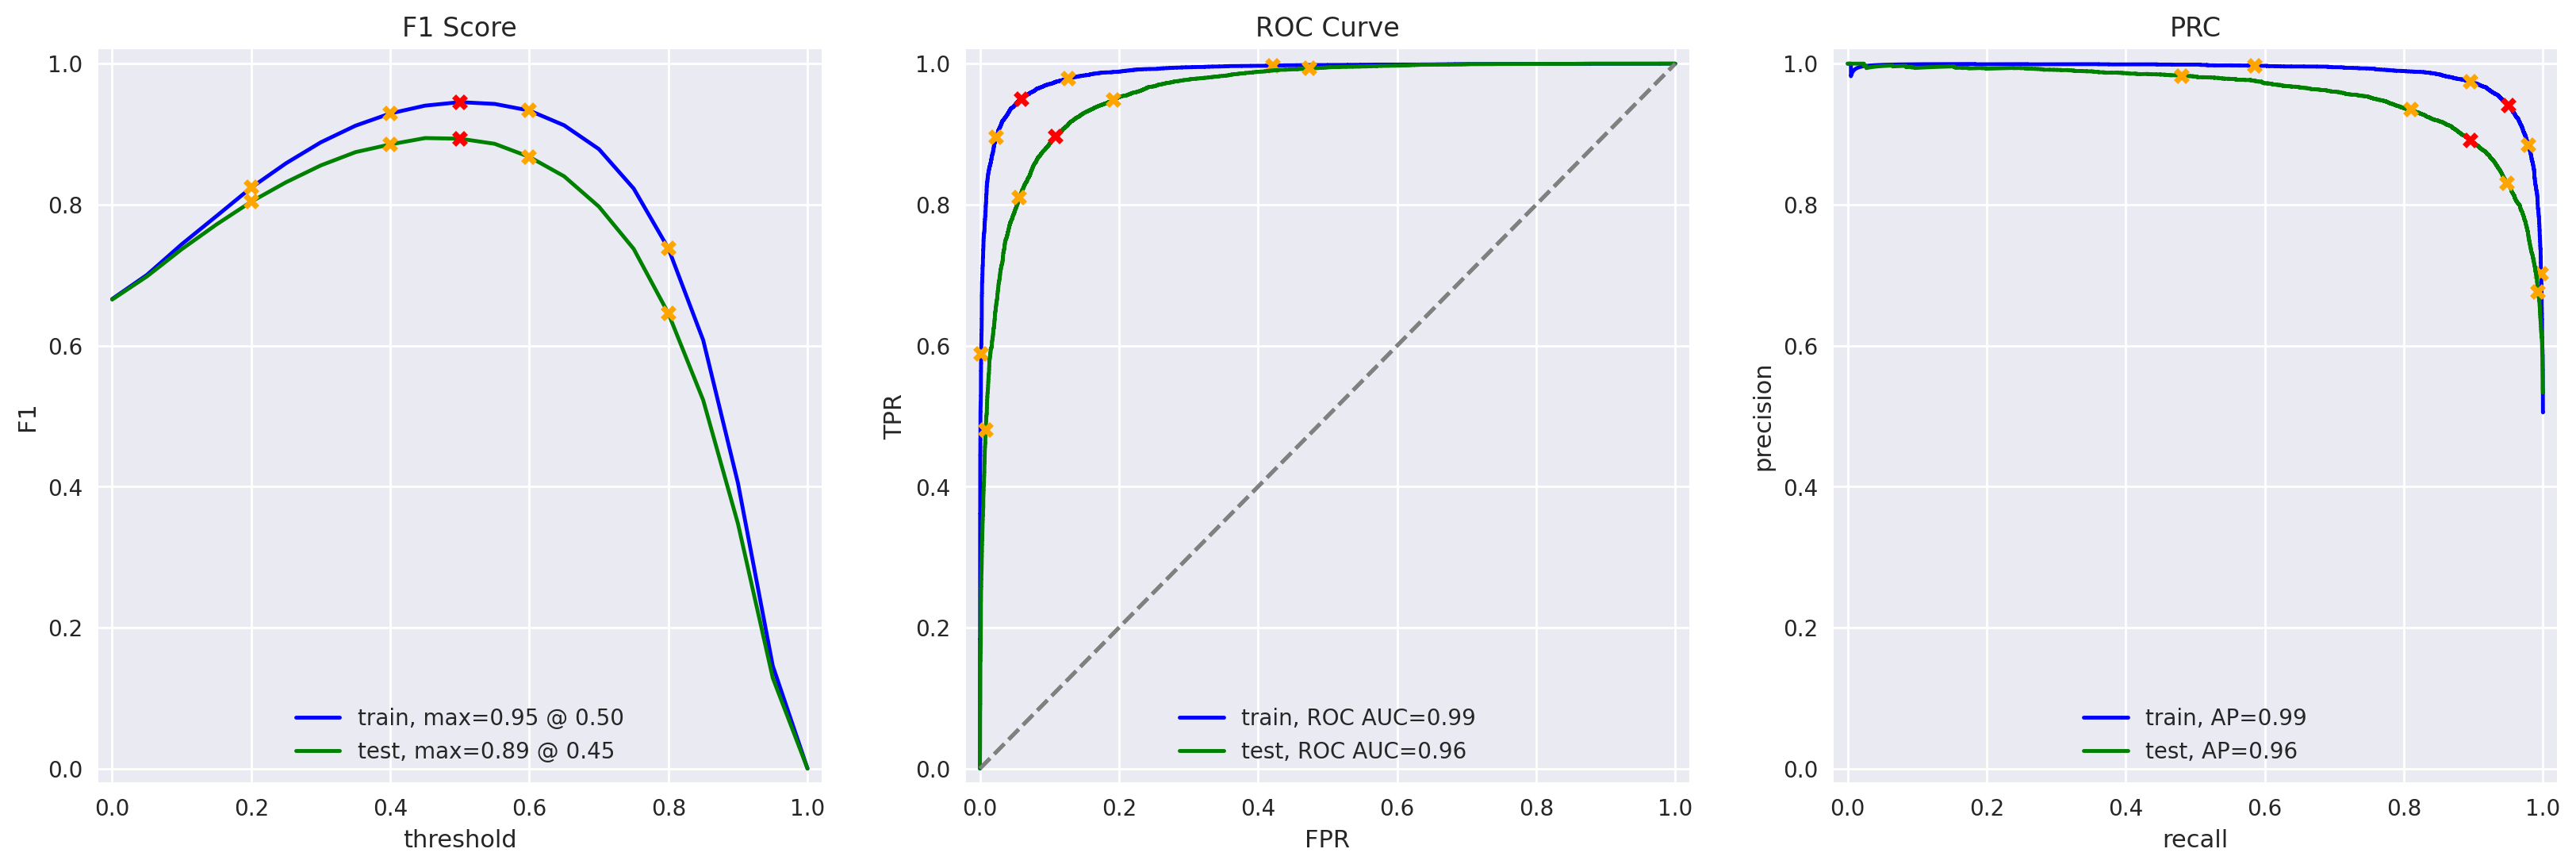

In [57]:
from sklearn.linear_model import LogisticRegression

model_1 = LogisticRegression(max_iter=1000, random_state=12345)

model_1.fit(train_features_1, train_target)

evaluate_model(
model_1,
train_features_1,
train_target,
test_features_1,
test_target
)

<div style="border: 5px solid gold; padding: 10px; margin: 5px">
<b>   Reviewer's comment 2 </b>
    

You don't need to repeat the code :) 
</div>

<div style="border: 5px solid red; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    
    
Would you please add a conclusion? 
</div>

# Conclusion
Model One uses TF-IDF features with Logistic Regression to clasify reviews. Its accuracy and F1 score show how well it performs compared with the Model Zero baseline.

### Model 3 - spaCy, TF-IDF and LR

In [58]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [59]:
def text_preprocessing_3(text):
    
    doc = nlp(text)
    #tokens = [token.lemma_ for token in doc if not token.is_stop]
    tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)

In [60]:
df_reviews_train['review_norm_3'] = df_reviews_train['review_norm'].progress_apply(text_preprocessing_3)
df_reviews_test['review_norm_3'] = df_reviews_test['review_norm'].progress_apply(text_preprocessing_3)

  0%|          | 0/23796 [00:00<?, ?it/s]

  0%|          | 0/23535 [00:00<?, ?it/s]

In [61]:
vectorizer_3 = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

train_features_3 = vectorizer_3.fit_transform(df_reviews_train['review_norm_3'])
test_features_3 = vectorizer_3.transform(df_reviews_test['review_norm_3'])

print("Training features shape:", train_features_3.shape)
print("Test features shape:", test_features_3.shape)

Training features shape: (23796, 50000)
Test features shape: (23535, 50000)


In [62]:
model_3 = LogisticRegression(max_iter=1000, random_state=12345)
model_3.fit(train_features_3, train_target)

LogisticRegression(max_iter=1000, random_state=12345)

In [69]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
test_pred_3 = model_3.predict(test_features_3)
test_prob_3 = model_3.predict_proba(test_features_3)[:, 1]

accuracy_3 = accuracy_score(test_target, test_pred_3)
f1_3 = f1_score(test_target, test_pred_3)
roc_auc_3 = roc_auc_score(test_target, test_prob_3)

print("Accuracy:", accuracy_3)
print("F1 Score:", f1_3)
print("ROC-AUC Score:", roc_auc_3)

Accuracy: 0.8925430210325048
F1 Score: 0.8925612812778793
ROC-AUC Score: 0.9591397721181278


<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment 2 </b>
    

Correct. 
</div>
<div style="border: 5px solid gold; padding: 10px; margin: 5px">
<b>   Reviewer's comment 2 </b>
    

You can also call the evaluation function.

</div>

<div style="border: 5px solid red; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    
    
We also need to evaluate the model. If we just train it and don't look at its performance, how can we say anything about it? 

</div>

# Conclusion
Model 3 achieved 89% accuracy and an F1 score of 0.89, with a ROC-AUC score of 0.959. These results indicate strong classification performance.

### Model 4 - spaCy, TF-IDF and LGBMClassifier

In [70]:
from lightgbm import LGBMClassifier

In [71]:
vectorizer_4 = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

train_features_4 = vectorizer_4.fit_transform(df_reviews_train['review_norm_3'])
test_features_4 = vectorizer_4.transform(df_reviews_test['review_norm_3'])

print("Training features shape:", train_features_4.shape)
print("Test features shape:", test_features_4.shape)

Training features shape: (23796, 50000)
Test features shape: (23535, 50000)


In [72]:
model_4 = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=10,
    random_state=12345
)
model_4.fit(train_features_4, train_target)

LGBMClassifier(max_depth=10, n_estimators=200, random_state=12345)

          train  test
Accuracy   0.96  0.87
F1         0.96  0.87
APS        0.99  0.94
ROC AUC    0.99  0.94


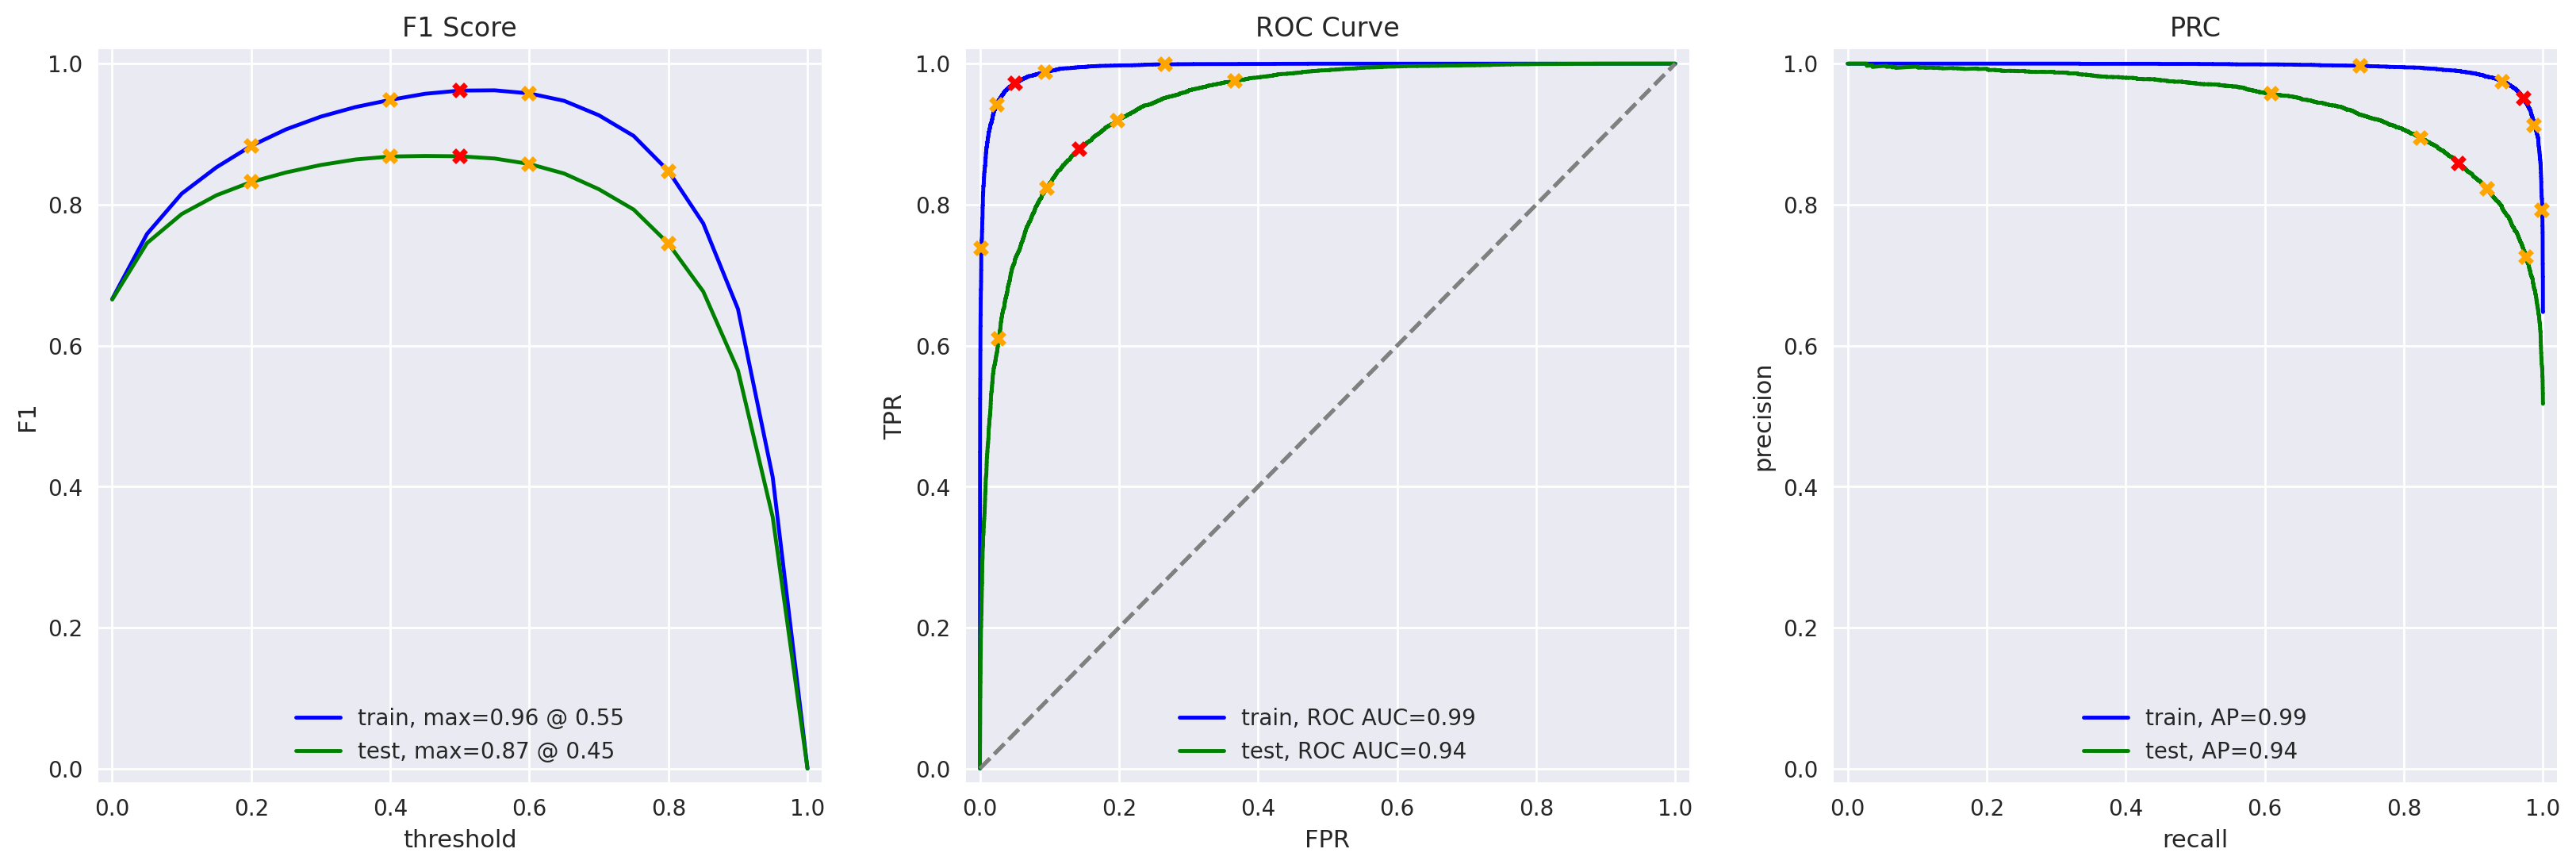

In [73]:
evaluate_model(model_4, train_features_4, train_target, test_features_4, test_target)

<div style="border: 5px solid red; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    
    
Please add a conclusion about this model as well. 
</div>

# Conclusion

Model 4 uses TF-IDF features with a LightGBM classifier to classify reviews. The model was evaluated using accuracy and F1 score, providing a basis for comparing its performance with the other models.

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment 2 </b>
    

Good job.
</div>

###  Model 9 - BERT

In [ ]:
import torch
import transformers

In [ ]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

In [ ]:
def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):
    
    ids_list = []
    attention_mask_list = []

    # text to padded ids of tokens along with their attention masks
    
    # <put your code here to create ids_list and attention_mask_list>
    
    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    model.to(device)
    if not disable_progress_bar:
        print(f'Using the {device} device.')
    
    # gettings embeddings in batches

    embeddings = []

    for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):
            
        ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
        # <put your code here to create attention_mask_batch
            
        with torch.no_grad():            
            model.eval()
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)   
        embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())
        
    return np.concatenate(embeddings)

In [ ]:
# Attention! Running BERT for thousands of texts may take long run on CPU, at least several hours
train_features_9 = BERT_text_to_embeddings(df_reviews_train['review_norm'], force_device='cuda')

In [ ]:
print(df_reviews_train['review_norm'].shape)
print(train_features_9.shape)
print(train_target.shape)

In [ ]:
# if you have got the embeddings, it's advisable to save them to have them ready if 
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# and load...
# with np.load('features_9.npz') as data:
#     train_features_9 = data['train_features_9']
#     test_features_9 = data['test_features_9']

## My Reviews

In [74]:
# feel free to completely remove these reviews and try your models on your own reviews, those below are just examples

my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',    
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])

my_reviews_norm = my_reviews['review'].str.lower().str.replace(r'[^a-zA-Z\s]', ' ', regex=True)
my_reviews_norm

0      i did not simply like it  not my kind of movie 
1    well  i was bored and felt asleep in the middl...
2               i was really fascinated with the movie
3    even the actors looked really old and disinter...
4    i didn t expect the reboot to be so good  writ...
5    the movie had its upsides and downsides  but i...
6    what a rotten attempt at a comedy  not a singl...
7    launching on netflix was a brave move   i real...
Name: review, dtype: object

<div style="border: 5px solid green; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    
Correct! 

</div>

### Model 2

In [75]:
tfidf_vectorizer_2 = vectorizer
model_2 = model_1

In [76]:

texts = my_reviews['review']

my_reviews_pred_prob = model_2.predict_proba(tfidf_vectorizer_2.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')


0.23:  I did not simply like it, not my kind of movie.
0.27:  Well, I was bored and felt asleep in the middle of the movie.
0.51:  I was really fascinated with the movie
0.12:  Even the actors looked really old and disinterested, and they got paid to be in the movie. What a so
0.35:  I didn't expect the reboot to be so good! Writers really cared about the source material
0.67:  The movie had its upsides and downsides, but I feel like overall it's a decent flick. I could see my
0.11:  What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even ki
0.75:  Launching on Netflix was a brave move & I really appreciate being able to binge on episode after epi


### Model 3

In [77]:
tfidf_vectorizer_3 = vectorizer_3

<div style="border: 5px solid gold; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    
Instead of duplicating objects, you can use the existing variables.
</div>

Updated the code to reuse the exsisting variables instead of duplicating objects, making the code more organized and streamlined.

In [78]:
vectorizer_3

TfidfVectorizer(max_df=0.95, max_features=50000, min_df=2, ngram_range=(1, 2))

### Model 4

In [79]:
texts = my_reviews['review']

tfidf_vectorizer_4 = tfidf_vectorizer_3
my_reviews_pred_prob = model_4.predict_proba(tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.72:  I did not simply like it, not my kind of movie.
0.55:  Well, I was bored and felt asleep in the middle of the movie.
0.66:  I was really fascinated with the movie
0.45:  Even the actors looked really old and disinterested, and they got paid to be in the movie. What a so
0.50:  I didn't expect the reboot to be so good! Writers really cared about the source material
0.79:  The movie had its upsides and downsides, but I feel like overall it's a decent flick. I could see my
0.44:  What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even ki
0.69:  Launching on Netflix was a brave move & I really appreciate being able to binge on episode after epi


<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
    
Nice results! 
</div>


### Model 9

In [ ]:
texts = my_reviews['review_norm']

my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

## Conclusions

The exploratory data analysis showed that the training and test datasets are well balanced, with approximately 50% negative and 50% positive reviews. The distributions of reviews across years and movies were also broadly similar between the training and test datasets. Therefore, no additional class-balancing techniques were necessary.


The models were able to classify positive and negative IMDb reviews effectively. The NLTK + TF-IDF + Logistic Regression model achieved a test F1 score of 0.89, exceeding the required minimum F1 score of 0.85. The other models were also evaluated on the test dataset, allowing their performance to be compared using F1, accuracy, APS, and ROC AUC.


Overall, the project successfully developed models capable of detecting the sentiment of IMDb movie reviews. The models performed well on the test data, although their predictions on the custom reviews may differ because different preprocessing methods and algorithms can interpret the same language differently. BERT was not used because it was optional and computationally demanding. The results demonstrate that traditional NLP techniques such as TF-IDF combined with classification models can achieve the required performance for this task.


<div style="border: 5px solid green; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    

Excellent, thank you so much! 

</div>


# Checklist

- [x]  Notebook was opened
- [x]  The text data is loaded and pre-processed for vectorization
- [x]  The text data is transformed to vectors
- [x]  Models are trained and tested
- [x]  The metric's threshold is reached
- [x]  All the code cells are arranged in the order of their execution
- [x]  All the code cells can be executed without errors
- [x]  There are conclusions